In [1]:
import sys
import os
# This is to ensure that the spack-installed packages are available in the environment
sys.path.append('/mnt/system/spack_nfs/spack_24Q2/spack_main/var/spack/environments/python-3p9-torch2-cuda12-24Q2/.spack-env/view/lib/python3.11/site-packages')
sys.path.append(os.path.dirname(os.path.abspath(os.getcwd())))
sys.path.append(os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), "collective_encoder"))


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt 
from matplotlib import cm
import MDAnalysis as mda
from MDAnalysis.analysis.dihedrals import Ramachandran

from collective_encoder.utils import compute_mfpt_matrix

In [3]:
run_folder = 'ala2/solvated/300K/ala2_100ns'
# run_folder = 'ala2/ala2_10ns'

traj_file = os.path.join(run_folder, 'md.xtc')
# tpr_file = os.path.join(run_folder, 'md.tpr')
tpr_file = os.path.join(run_folder, '../initialization', 'tpr_initial.tpr')


In [4]:
u = mda.Universe(tpr_file, traj_file)
print(len(u.trajectory))


1000001


In [5]:
ala = u.select_atoms('resname ALA')
Rama = Ramachandran(ala).run(step=10, verbose=True)
phi = Rama.angles[:, 0, 0] / 180 * np.pi
psi = Rama.angles[:, 0, 1] / 180 * np.pi

  0%|          | 0/100001 [00:00<?, ?it/s]

/mnt/projects/sne/Gohar/software_deck/pyenv-ml/lib/python3.12/site-packages/MDAnalysis/analysis/dihedrals.py:574: DeprecationWarning: The `angle` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.angles` instead
  warnings.warn(wmsg, DeprecationWarning)


In [6]:
print(phi.shape, psi.shape)

(100001,) (100001,)


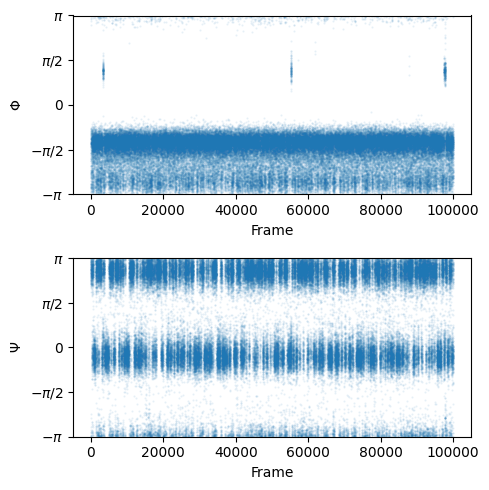

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(5,5))

ax[0].scatter(range(len(phi)), phi, marker='.', s=1, alpha=0.1)
ax[0].set_xlabel("Frame")
ax[0].set_ylabel(r"$\Phi$")
ax[0].set_ylim([-np.pi, np.pi])
ax[0].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax[0].set_yticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])

ax[1].scatter(range(len(psi)), psi, marker='.', s=1, alpha=0.1)
ax[1].set_xlabel("Frame")
ax[1].set_ylabel(r"$\Psi$")
ax[1].set_ylim([-np.pi, np.pi])
ax[1].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax[1].set_yticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])

plt.tight_layout()


[Text(-3.141592653589793, 0, '$-\\pi$'),
 Text(-1.5707963267948966, 0, '$-\\pi/2$'),
 Text(0.0, 0, '0'),
 Text(1.5707963267948966, 0, '$\\pi/2$'),
 Text(3.141592653589793, 0, '$\\pi$')]

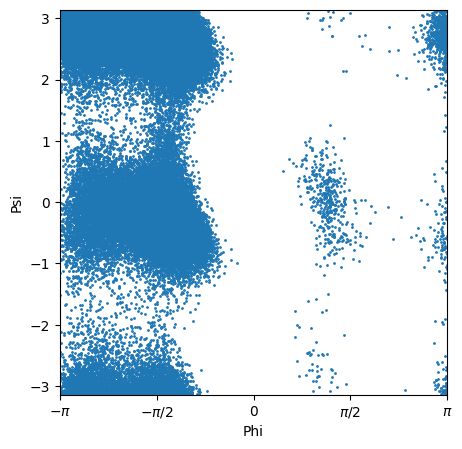

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(5,5))

ax.scatter(phi, psi, s=1)
ax.set_xlabel("Phi")
ax.set_ylabel("Psi")
ax.set_xlim([-np.pi, np.pi])
ax.set_ylim([-np.pi, np.pi])
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])


# Identify metastable states using BFGS solvers

In [9]:
'''
1) Use a standard Gaussian kernel density estimator (Scott, 1992) to approximate the free energy surface in the space of the two dihedral angles ϕ, ψ 
2) Run 100 BFGS solvers (Nocedal & Wright, 2006) initialized at random points and run until convergence from which we recover the unique local minima. 

By doing so, we are able to reliably identify metastable states without the need for manual specification
'''

def periodic_norm_distance(x1, x2, period=2*np.pi):
    """ Compute the periodic norm distance between two points x1 and x2 """
    # Minimum image convention
    d = (x1 - x2 + period/2) % period - period/2
    
    return np.linalg.norm(d)

def periodic_average(x, period=2*np.pi):
    """ Compute the periodic average of a list of 2D points x """
    # Minimum image convention
    x = np.array(x)
    x1 = np.arctan2(np.mean(np.sin(x[:,0])), np.mean(np.cos(x[:,0])))
    x2 = np.arctan2(np.mean(np.sin(x[:,1])), np.mean(np.cos(x[:,1])))
    return np.array([x1, x2])
    
sigma = 0.2 # bandwidth for KDE
bin_x = 200
bin_y = 200
minima_tolerance = 0.15
n_BFGS_runs = 100

# Step 1
from sklearn.neighbors import KernelDensity
X = np.stack([phi, psi], axis=-1)
kde = KernelDensity(kernel='gaussian', bandwidth=sigma).fit(X) # bandwidth is sigma

# Step 2
from scipy.optimize import minimize
def objective(x):
    return -kde.score_samples(x.reshape(1, -1))
results = []
for _ in range(n_BFGS_runs):
    x0 = np.random.uniform(-np.pi, np.pi, size=2)
    res = minimize(objective, x0, method='BFGS')
    results.append(res)
min_points = np.array([r.x for r in results if r.success])
# Remove points whole norm are closer than 'minima_tolerance'
min_points_reduced = []
for p in min_points:
    for q in min_points_reduced:
        if any(periodic_norm_distance(np.array(p), np.array(r)) <= minima_tolerance for r in q):
            q.append(p)
            break
    else:
        min_points_reduced.append([p])
min_points = np.array([periodic_average(a) for a in min_points_reduced])
print("Number of local minima found:", len(min_points))
print(min_points)

Number of local minima found: 11
[[ 3.03196101 -0.66485787]
 [ 1.02826202 -2.71076147]
 [-2.69038603  2.78350522]
 [-1.31441031 -0.3401345 ]
 [ 3.07450595 -3.01082892]
 [-2.63080504 -2.9917996 ]
 [ 1.20116285  0.05799971]
 [-1.28428134  2.67126531]
 [ 3.03413492  2.75833822]
 [-1.4946283  -3.01094887]
 [ 1.2054374   2.96417119]]


## Populate grid

In [10]:
x = np.linspace(-np.pi, np.pi, bin_x) # grid points
y = np.linspace(-np.pi, np.pi, bin_y)
Xgrid, Ygrid = np.meshgrid(x, y)
# Free energy surface
kbt = 0.415 # at 300K in kJ/mol
fes = kbt * -kde.score_samples(np.vstack([Xgrid.ravel(), Ygrid.ravel()]).T).reshape(Xgrid.shape)
fes -= fes.min() # set minimum to zero

In [11]:
min_vals = np.array([float(objective(p)[0]) for p in min_points])
print("Objective values at minima:", min_vals)
# Sorting minima based on their depth
sorted_indices = np.argsort(min_vals)
min_points = min_points[sorted_indices]
min_vals = min_vals[sorted_indices]
print("Sorted objective values at minima:\n", min_vals)
print("Sorted minima points:\n", min_points)

Objective values at minima: [6.43345708 7.29202428 1.58586693 0.71284906 6.34486881 3.10734025
 5.32237448 0.80958371 4.38060108 2.98652604 7.92120233]
Sorted objective values at minima:
 [0.71284906 0.80958371 1.58586693 2.98652604 3.10734025 4.38060108
 5.32237448 6.34486881 6.43345708 7.29202428 7.92120233]
Sorted minima points:
 [[-1.31441031 -0.3401345 ]
 [-1.28428134  2.67126531]
 [-2.69038603  2.78350522]
 [-1.4946283  -3.01094887]
 [-2.63080504 -2.9917996 ]
 [ 3.03413492  2.75833822]
 [ 1.20116285  0.05799971]
 [ 3.07450595 -3.01082892]
 [ 3.03196101 -0.66485787]
 [ 1.02826202 -2.71076147]
 [ 1.2054374   2.96417119]]


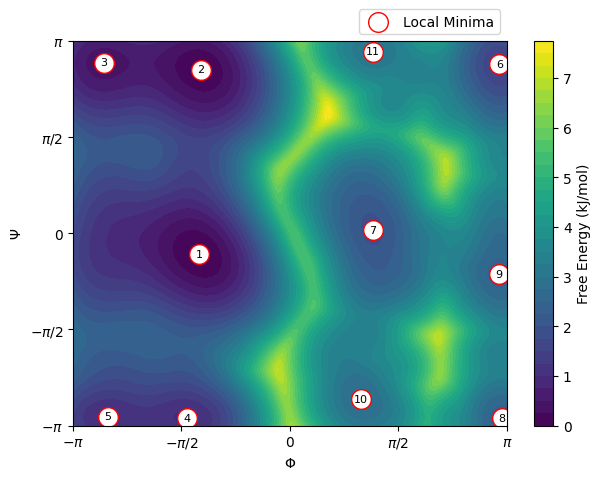

In [12]:
# Plot
fig, ax = plt.subplots(1, 1, figsize=(7,5))
cf = ax.contourf(Xgrid, Ygrid, fes, levels=30, cmap=cm.viridis)
fig.colorbar(cf, ax=ax, label='Free Energy (kJ/mol)')
ax.scatter(min_points[:,0], min_points[:,1], 
           facecolors='w', edgecolors='r', s=200, 
           label='Local Minima')
for i, (x, y) in enumerate(min_points):
    ax.text(x, y, str(i + 1), color='black', fontsize=8, ha='center', va='center')
ax.set_xlabel(r"$\Phi$")
ax.set_ylabel(r"$\Psi$")
ax.set_xlim([-np.pi, np.pi])
ax.set_ylim([-np.pi, np.pi])
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels([r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
ax.legend(bbox_to_anchor=(1, 1.1))
plt.show()

In [13]:
# states 
selected = [12,11,4,2,6] # choose which states to consider
selected_idx = [i-1 for i in selected]

print("Selected states:", min_points[selected_idx])


IndexError: index 11 is out of bounds for axis 0 with size 11

## MFPT metrics

0.0009531752651018706 0.9314468165028486
  Shape: (5, 5)
  Lag time: 1
  Transition counts:
[[1.0189e+04 3.1980e+03 1.7110e+03 4.4100e+02 2.0600e+02]
 [3.1790e+03 2.7936e+04 1.2750e+03 3.2000e+01 1.1500e+03]
 [1.7400e+03 1.2260e+03 4.4634e+04 1.4900e+02 1.7000e+02]
 [4.3900e+02 3.8000e+01 1.4700e+02 4.5800e+02 8.0000e+00]
 [1.9800e+02 1.1730e+03 1.5300e+02 1.0000e+01 1.4000e+02]]
  MFPT Matrix:
[[  0.          10.61769426  14.6905263  153.13301071  67.60296506]
 [ 13.41091723   0.          17.70795878 162.57314183  61.82847769]
 [ 20.62865506  21.0901234    0.         164.73589755  76.65576715]
 [  7.4994421   14.06435346  13.20404615   0.          70.23035061]
 [ 13.45253231   4.65693343  16.61421142 161.60184081   0.        ]]


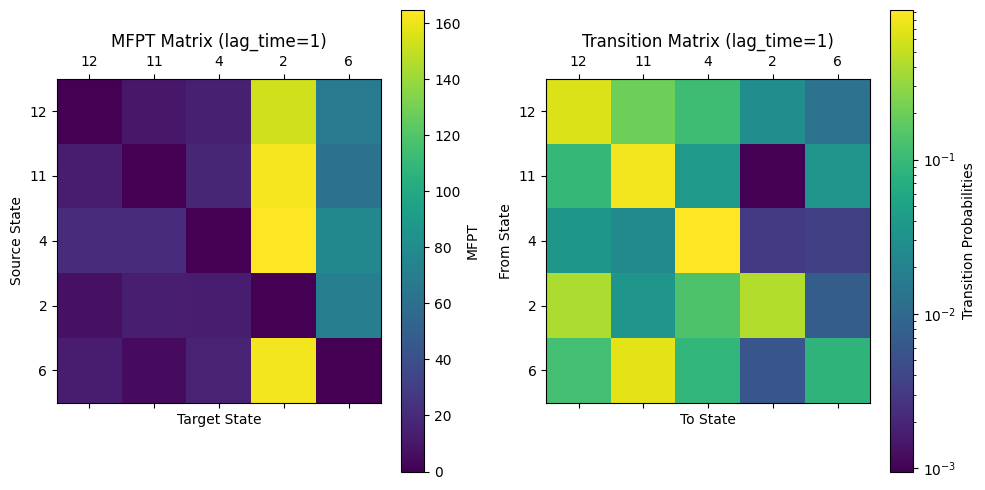

In [ ]:
from matplotlib.colors import LogNorm


lag_time = 1
minima = min_points[selected_idx]
msm_data = np.stack([phi, psi], axis=-1)
# n_max_states = 4
# if len(minima) > n_max_states:
#     minima = minima[:n_max_states]
transition_counts, transition_matrix, mfpt_matrix = compute_mfpt_matrix(msm_data, minima, lag=lag_time)


fig, ax = plt.subplots(1, 2, figsize=(10,5))
# Plot MFPT matrix
ax[0].matshow(mfpt_matrix, cmap='viridis')
fig.colorbar(cm.ScalarMappable(cmap='viridis', 
                               norm=plt.Normalize(vmin=mfpt_matrix.min(), vmax=mfpt_matrix.max())), 
                               ax=ax[0], 
                               label='MFPT')
ax[0].set_title(f'MFPT Matrix (lag_time={lag_time})')
ax[0].set_xlabel('Target State')
ax[0].set_ylabel('Source State')
ax[0].set_xticks(np.arange(len(minima)))
ax[0].set_yticks(np.arange(len(minima)))
ax[0].set_xticklabels([str(i) for i in selected])
ax[0].set_yticklabels([str(i) for i in selected])


# Plot Transition counts 
print(transition_matrix.min(), transition_matrix.max())
tm_norm = LogNorm(vmin=transition_matrix.min(), vmax=transition_matrix.max())
# transition_matrix = np.log1p(transition_matrix)
ax[1].matshow(transition_matrix, cmap='viridis', norm=tm_norm)
fig.colorbar(cm.ScalarMappable(cmap='viridis', 
                               norm=tm_norm), 
                               ax=ax[1], 
                               label='Transition Probabilities')
ax[1].set_title(f'Transition Matrix (lag_time={lag_time})')
ax[1].set_xlabel('To State')
ax[1].set_ylabel('From State')
ax[1].set_xticks(np.arange(len(minima)))
ax[1].set_yticks(np.arange(len(minima)))
ax[1].set_xticklabels([str(i) for i in selected])
ax[1].set_yticklabels([str(i) for i in selected])

fig.tight_layout()


print(f"  Shape: {mfpt_matrix.shape}")
print(f"  Lag time: {lag_time}")
print(f"  Transition counts:\n{transition_counts}")
print(f"  MFPT Matrix:\n{mfpt_matrix}")


# Free-Energy surface using gaussian kernel dessity estimation

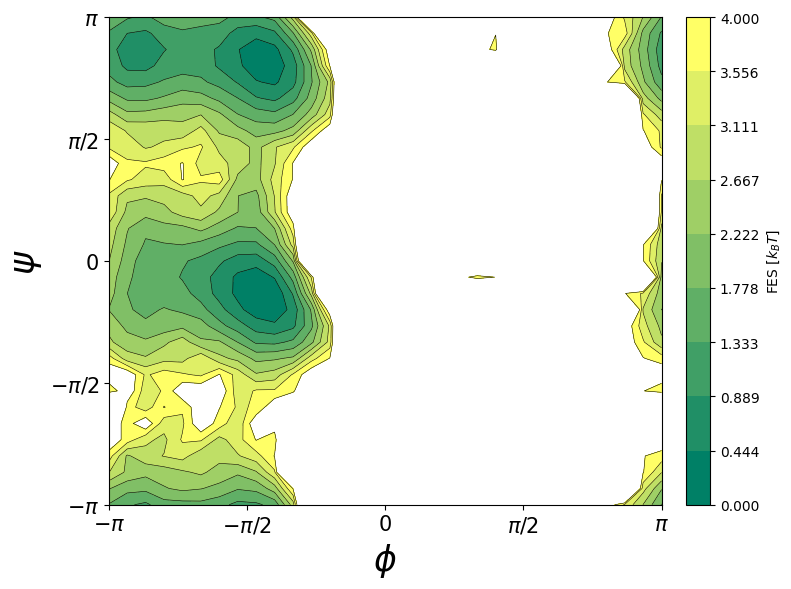

In [ ]:
def free_energy_weights(a, b, T, y0, ymax, x0, xmax, w = None):
    free_energy, xedges, yedges = np.histogram2d(
        a, b, 30, [[y0, ymax], [x0, xmax]], density=True, weights=w)
    free_energy = np.log(free_energy + .000001)
    free_energy = -(0.001987*T) * free_energy
    return free_energy, xedges, yedges

dG, xedges, yedges = free_energy_weights(psi, phi, 300, -3.14, 3.14, -3.14, 3.14)

if False:
    dG -= np.amax(dG)
elif True:
    dG -= np.amin(dG)

lmax = 4#np.amax(dG)
lmin = np.amin(dG)
nlevels = 10
levels = np.linspace(lmin, lmax, nlevels)#np.arange(lmin, lmax, (lmax-lmin)/nlevels)
norm = cm.colors.Normalize(vmax=lmax, vmin=lmin)
# norm = cm.colors.Normalize(vmax=np.amax(fes), vmin=-lmax)
# cmap = cm.viridis
cmap = cm.summer
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))

x = xedges
y = yedges
dG = np.concatenate((dG, dG[:, 0:1]), axis=1) # periodic boundary
dG = np.concatenate((dG, dG[0:1, :]), axis=0) # periodic boundary

cset1 = ax.contourf(x, y, dG, levels, norm=norm,
                        cmap=cmap.resampled(len(levels) - 1))


cset2 = ax.contour(x, y, dG, cset1.levels, colors='k',linewidths=0.4) # For contour lines

cb = fig.colorbar(cset1, ax=ax, label=r'FES $[k_{B}T]$', fraction=0.046, pad=0.04)

plt.ylabel(r"$\psi$", size=25)
plt.xlabel(r"$\phi$", size=25)
plt.xticks([-3.14, -1.57, 0, 1.57, 3.14], [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'], fontsize=15)
plt.yticks([-3.14, -1.57, 0, 1.57, 3.14], [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'], fontsize=15)
plt.tight_layout()
plt.show()




